In [68]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# Output folder for exported tables and figures
output_folder = "/Users/fa/Downloads/coursework_bundle"
os.makedirs(output_folder, exist_ok=True)

print("Current working directory:")
print(os.getcwd())

print("\nOutputs will be saved to:")
print(output_folder)

# G7 country codes and names
g7_codes = ['USA', 'GBR', 'JPN', 'DEU', 'FRA', 'ITA', 'CAN']
g7_names = ['United States', 'United Kingdom', 'Japan', 'Germany',
            'France', 'Italy', 'Canada']

Current working directory:
/Users/fa

Outputs will be saved to:
/Users/fa/Downloads/coursework_bundle


In [69]:
# Load the dataset
inflation_raw = pd.read_csv(
    '/Users/fa/Downloads/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv',
    skiprows=4,
    encoding='utf-8-sig'
)

oil_raw = pd.read_csv('/Users/fa/Downloads/crude_oil_prices.csv')

print('Inflation shape:', inflation_raw.shape)
print('Oil shape:', oil_raw.shape)

print("\nInflation data preview:")
print(inflation_raw.head())

print("\nOil data preview:")
print(oil_raw.head())


Inflation shape: (266, 71)
Oil shape: (33, 3)

Inflation data preview:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                          Indicator Name  Indicator Code  1960  1961  1962  \
0  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG   NaN   NaN   NaN   
1  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG   NaN   NaN   NaN   
2  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG   NaN   NaN   NaN   
3  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG   NaN   NaN   NaN   
4  Inflation, consumer prices (annual %)  FP.CPI.TOTL.ZG   NaN   NaN   NaN   

   1963  1964  1965  ...       2017       2018       2019       2020  \
0   NaN   NaN   NaN  ...  -1.028282   3.626041   4.257462        NaN   
1   NaN   NaN   NaN  ...   6.2213

In [70]:
# Clean the dataset

year_cols = []
for c in inflation_raw.columns:
    if str(c).isdigit():
        year_cols.append(c)

rows = []
for i in range(len(g7_codes)):
    country_row = inflation_raw[inflation_raw['Country Code'] == g7_codes[i]]
    for j in range(len(year_cols)):
        inf_val = country_row[year_cols[j]].values[0]
        rows.append({
            'Country': g7_names[i],
            'Year': int(year_cols[j]),
            'Inflation': inf_val
        })

inflation = pd.DataFrame(rows)
inflation = inflation.dropna()

In [71]:
# Merge the dataset

df = inflation.merge(oil_raw[['Year', 'Oil_Price_Change']], on='Year')
df = df[(df['Year'] >= 1992) & (df['Year'] <= 2024)]
df = df.sort_values(['Country', 'Year'])
df = df.reset_index(drop=True)

print('Final panel shape:', df.shape)
print(df.head())

Final panel shape: (231, 4)
  Country  Year  Inflation  Oil_Price_Change
0  Canada  1992   1.490133         -3.400231
1  Canada  1993   1.865079        -12.158908
2  Canada  1994   0.165563         -6.799632
3  Canada  1995   2.148760          7.580493
4  Canada  1996   1.570531         21.460176


In [72]:
# Check the dataset 

print('Missing values:')
print(df.isna().sum())
print()
print('Observations per country:')
print(df.groupby('Country')['Year'].count())

Missing values:
Country             0
Year                0
Inflation           0
Oil_Price_Change    0
dtype: int64

Observations per country:
Country
Canada            33
France            33
Germany           33
Italy             33
Japan             33
United Kingdom    33
United States     33
Name: Year, dtype: int64


In [73]:
# Table 1: Descriptive statistics 

desc = df.groupby('Country')[['Inflation', 'Oil_Price_Change']].agg(['mean', 'std', 'min', 'max'])
desc = desc.round(2)
desc

Inflation                   Oil_Price_Change                \
                    mean   std   min   max             mean    std    min   
Country                                                                     
Canada              2.04  1.17  0.17  6.80             8.15  28.55 -47.06   
France              1.67  1.12  0.04  5.22             8.15  28.55 -47.06   
Germany             2.01  1.54  0.14  6.87             8.15  28.55 -47.06   
Italy               2.42  1.85 -0.14  8.20             8.15  28.55 -47.06   
Japan               0.49  1.14 -1.35  3.27             8.15  28.55 -47.06   
United Kingdom      2.49  1.53  0.37  7.92             8.15  28.55 -47.06   
United States       2.57  1.43 -0.36  8.00             8.15  28.55 -47.06   

                       
                  max  
Country                
Canada          69.49  
France          69.49  
Germany         69.49  
Italy           69.49  
Japan           69.49  
United Kingdom  69.49  
United States   69.49

In [74]:
# Regression

def run_ols(data, x_cols, cov_type=None, cov_kwds=None):
    '''OLS of Inflation on x_cols. Optionally accepts cov_type for robust SEs.'''
    if type(x_cols) == str:
        x_cols = [x_cols]
    X = sm.add_constant(data[x_cols])
    y = data['Inflation']
    if cov_type is None:
        model = sm.OLS(y, X).fit()
    else:
        model = sm.OLS(y, X).fit(cov_type=cov_type, cov_kwds=cov_kwds)
    return model

In [75]:
# Table 2 : Country Regression

country_models = {}
rows = []

for country in g7_names:
    sub = df[df['Country'] == country]
    m = run_ols(sub, 'Oil_Price_Change')
    country_models[country] = m

    b = m.params['Oil_Price_Change']
    se = m.bse['Oil_Price_Change']
    t = m.tvalues['Oil_Price_Change']
    p = m.pvalues['Oil_Price_Change']

    if p < 0.01:
        stars = '***'
    elif p < 0.05:
        stars = '**'
    elif p < 0.1:
        stars = '*'
    else:
        stars = ''

    rows.append({
        'Country': country,
        'N': int(m.nobs),
        'Beta': round(b, 4),
        'Std_Error': round(se, 4),
        'T_Stat': round(t, 2),
        'P_Value': round(p, 4),
        'Sig': stars,
        'R_Squared': round(m.rsquared, 3),
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values('Beta', ascending=False)
results_df = results_df.reset_index(drop=True)
print(results_df)

          Country   N    Beta  Std_Error  T_Stat  P_Value  Sig  R_Squared
0   United States  33  0.0307     0.0071    4.32   0.0001  ***      0.376
1          Canada  33  0.0209     0.0063    3.32   0.0023  ***      0.263
2           Italy  33  0.0158     0.0113    1.40   0.1725           0.059
3          France  33  0.0142     0.0066    2.16   0.0385   **      0.131
4  United Kingdom  33  0.0120     0.0094    1.28   0.2100           0.050
5         Germany  33  0.0099     0.0095    1.04   0.3063           0.034
6           Japan  33 -0.0069     0.0071   -0.97   0.3380           0.030


In [76]:
# US detail

print(country_models['United States'].summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     18.67
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000148
Time:                        20:34:14   Log-Likelihood:                -50.324
No. Observations:                  33   AIC:                             104.6
Df Residuals:                      31   BIC:                             107.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.3200      0.208  

In [77]:
# Pooled OLS

pooled_model = run_ols(df, 'Oil_Price_Change')
print(pooled_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     15.33
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000119
Time:                        20:34:14   Log-Likelihood:                -421.37
No. Observations:                 231   AIC:                             846.7
Df Residuals:                     229   BIC:                             853.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.8426      0.103  

In [78]:
# Pooled with year-clustered Standard errors 

pooled_cluster = run_ols(
    df, 'Oil_Price_Change',
    cov_type='cluster',
    cov_kwds={'groups': df['Year']}
)
print(pooled_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     3.053
Date:                Wed, 13 May 2026   Prob (F-statistic):             0.0902
Time:                        20:34:14   Log-Likelihood:                -421.37
No. Observations:                 231   AIC:                             846.7
Df Residuals:                     229   BIC:                             853.6
Df Model:                           1                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.8426      0.199  

In [79]:
# Panel FE - country

df_panel = df.set_index(['Country', 'Year'])
y_panel = df_panel['Inflation']
X_panel = sm.add_constant(df_panel[['Oil_Price_Change']])

mod = PanelOLS(y_panel, X_panel, entity_effects=True)
fe_model = mod.fit()
print(fe_model)

print()
print('Note: Two-way fixed effects (country + time) cannot be identified here')
print('because oil-price change is the same for all G7 in any given year.')

                          PanelOLS Estimation Summary                           
Dep. Variable:              Inflation   R-squared:                        0.0771
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                 231   R-squared (Within):               0.0771
Date:                Wed, May 13 2026   R-squared (Overall):              0.0627
Time:                        20:34:14   Log-likelihood                   -395.81
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.628
Entities:                           7   P-value                           0.0000
Avg Obs:                       33.000   Distribution:                   F(1,223)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             18.628
                            

In [80]:
# Panel FE with standard errors

fe_cluster = mod.fit(cov_type='clustered', cluster_time=True)
print(fe_cluster)

                          PanelOLS Estimation Summary                           
Dep. Variable:              Inflation   R-squared:                        0.0771
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                 231   R-squared (Within):               0.0771
Date:                Wed, May 13 2026   R-squared (Overall):              0.0627
Time:                        20:34:14   Log-likelihood                   -395.81
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.628
Entities:                           7   P-value                           0.0000
Avg Obs:                       33.000   Distribution:                   F(1,223)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             3.0530
                            

In [81]:
# Sub period analysis 

period_rows = []

for country in g7_names:
    for label, start, end in [('1992-2007', 1992, 2007), ('2008-2024', 2008, 2024)]:
        sub = df[(df['Country'] == country) & (df['Year'] >= start) & (df['Year'] <= end)]
        if len(sub) >= 10:
            m = run_ols(sub, 'Oil_Price_Change')
            period_rows.append({
                'Country': country,
                'Period': label,
                'N': int(m.nobs),
                'Coefficient': round(m.params['Oil_Price_Change'], 4),
                'P_Value': round(m.pvalues['Oil_Price_Change'], 4),
                'R_Squared': round(m.rsquared, 3),
            })

period_df = pd.DataFrame(period_rows)
print('Per-country sub-periods:')
print(period_df)
print()

print('Pooled sub-periods:')
for label, start, end in [('1992-2007', 1992, 2007), ('2008-2024', 2008, 2024)]:
    sub = df[(df['Year'] >= start) & (df['Year'] <= end)]
    m = run_ols(sub, 'Oil_Price_Change')
    print(label, '  beta =', round(m.params['Oil_Price_Change'], 4),
          ' R2 =', round(m.rsquared, 3),
          ' p =', round(m.pvalues['Oil_Price_Change'], 3),
          ' n =', int(m.nobs))

Per-country sub-periods:
           Country     Period   N  Coefficient  P_Value  R_Squared
0    United States  1992-2007  16       0.0109   0.0588      0.232
1    United States  2008-2024  17       0.0411   0.0023      0.472
2   United Kingdom  1992-2007  16      -0.0093   0.3052      0.075
3   United Kingdom  2008-2024  17       0.0250   0.0956      0.174
4            Japan  1992-2007  16      -0.0168   0.0499      0.247
5            Japan  2008-2024  17      -0.0002   0.9821      0.000
6          Germany  1992-2007  16      -0.0181   0.1605      0.136
7          Germany  2008-2024  17       0.0250   0.0766      0.194
8           France  1992-2007  16       0.0018   0.7494      0.008
9           France  2008-2024  17       0.0209   0.0685      0.204
10           Italy  1992-2007  16      -0.0149   0.2728      0.085
11           Italy  2008-2024  17       0.0295   0.0809      0.189
12          Canada  1992-2007  16       0.0120   0.0808      0.202
13          Canada  2008-2024  17    

In [82]:
# Structual break test

df['Post2008'] = (df['Year'] >= 2008).astype(int)
df['Oil_x_Post'] = df['Oil_Price_Change'] * df['Post2008']

break_model = run_ols(df, ['Oil_Price_Change', 'Post2008', 'Oil_x_Post'])
print(break_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     10.91
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.01e-06
Time:                        20:34:14   Log-Likelihood:                -413.30
No. Observations:                 231   AIC:                             834.6
Df Residuals:                     227   BIC:                             848.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.9856      0.152  

In [83]:
# Robustness test with 2022 excluded

robustness_rows = []

for label, exclude_years in [('Post-2008 (full)', []),
                              ('Post-2008 excl. 2022', [2022]),
                              ('Post-2008 excl. 2020 and 2022', [2020, 2022])]:
    sub = df[(df['Year'] >= 2008) & (df['Year'] <= 2024)]
    for y in exclude_years:
        sub = sub[sub['Year'] != y]
    m = run_ols(sub, 'Oil_Price_Change')
    robustness_rows.append({
        'Specification': label,
        'Beta': round(m.params['Oil_Price_Change'], 4),
        'Std_Error': round(m.bse['Oil_Price_Change'], 4),
        'P_Value': round(m.pvalues['Oil_Price_Change'], 4),
        'R_Squared': round(m.rsquared, 3),
        'N': int(m.nobs),
    })

robustness_df = pd.DataFrame(robustness_rows)
print(robustness_df)

                   Specification    Beta  Std_Error  P_Value  R_Squared    N
0               Post-2008 (full)  0.0240     0.0049   0.0000      0.171  119
1           Post-2008 excl. 2022  0.0147     0.0041   0.0005      0.105  112
2  Post-2008 excl. 2020 and 2022  0.0128     0.0044   0.0044      0.076  105


In [84]:
# Lagged oil

df['Oil_Price_Change_Lag'] = np.nan

for country in g7_names:
    country_idx = df[df['Country'] == country].index
    for k in range(1, len(country_idx)):
        df.loc[country_idx[k], 'Oil_Price_Change_Lag'] = df.loc[country_idx[k-1], 'Oil_Price_Change']

df_lag = df.dropna(subset=['Oil_Price_Change_Lag']).copy()
print('Lag dataset shape:', df_lag.shape)

Lag dataset shape: (224, 7)


In [85]:
#Table 3: Lag comparison

comparison_rows = []
lag_models = {}

for country in g7_names:
    sub = df_lag[df_lag['Country'] == country]
    m1 = run_ols(sub, 'Oil_Price_Change')
    m2 = run_ols(sub, ['Oil_Price_Change', 'Oil_Price_Change_Lag'])
    lag_models[country] = m2

    comparison_rows.append({
        'Country': country,
        'R2_Baseline': round(m1.rsquared, 3),
        'R2_Lagged': round(m2.rsquared, 3),
        'Improvement': round(m2.rsquared - m1.rsquared, 3),
        'Lag_Coef': round(m2.params['Oil_Price_Change_Lag'], 4),
        'Lag_P': round(m2.pvalues['Oil_Price_Change_Lag'], 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

          Country  R2_Baseline  R2_Lagged  Improvement  Lag_Coef   Lag_P
0   United States        0.384      0.517        0.132    0.0183  0.0086
1  United Kingdom        0.063      0.229        0.167    0.0212  0.0182
2           Japan        0.026      0.047        0.021    0.0056  0.4344
3         Germany        0.050      0.212        0.162    0.0204  0.0211
4          France        0.139      0.366        0.227    0.0186  0.0031
5           Italy        0.075      0.247        0.172    0.0260  0.0155
6          Canada        0.260      0.416        0.157    0.0162  0.0092


In [86]:
# Table 5: Cumilative pass-through

cumulative_rows = []

for country in g7_names:
    m = lag_models[country]
    b0 = m.params['Oil_Price_Change']
    b1 = m.params['Oil_Price_Change_Lag']
    cumulative_rows.append({
        'Country': country,
        'Beta_Year_0': round(b0, 4),
        'Beta_Year_1': round(b1, 4),
        'Cumulative': round(b0 + b1, 4),
    })

cumulative_df = pd.DataFrame(cumulative_rows)
cumulative_df = cumulative_df.sort_values('Cumulative', ascending=False)
cumulative_df = cumulative_df.reset_index(drop=True)
print(cumulative_df)

          Country  Beta_Year_0  Beta_Year_1  Cumulative
0   United States       0.0298       0.0183      0.0481
1           Italy       0.0154       0.0260      0.0413
2          Canada       0.0196       0.0162      0.0358
3  United Kingdom       0.0115       0.0212      0.0327
4          France       0.0133       0.0186      0.0319
5         Germany       0.0099       0.0204      0.0304
6           Japan      -0.0067       0.0056     -0.0011


In [98]:
# Summary table using year-clustered standard errors for pooled and FE rows
summary_rows = []

summary_rows.append({
    'Specification': 'Pooled OLS',
    'Beta': round(pooled_cluster.params['Oil_Price_Change'], 4),
    'Std_Error': round(pooled_cluster.bse['Oil_Price_Change'], 4),
    'P_Value': round(pooled_cluster.pvalues['Oil_Price_Change'], 4),
    'R_Squared': round(pooled_cluster.rsquared, 3),
    'N': int(pooled_cluster.nobs),
})

summary_rows.append({
    'Specification': 'Panel FE (country)',
    'Beta': round(float(fe_cluster.params['Oil_Price_Change']), 4),
    'Std_Error': round(float(fe_cluster.std_errors['Oil_Price_Change']), 4),
    'P_Value': round(float(fe_cluster.pvalues['Oil_Price_Change']), 4),
    'R_Squared': round(float(fe_cluster.rsquared_within), 3),
    'N': int(fe_cluster.nobs),
})

sub_pre = df[(df['Year'] >= 1992) & (df['Year'] <= 2007)]
m_pre = run_ols(sub_pre, 'Oil_Price_Change')
summary_rows.append({
    'Specification': 'Pre-2008 (pooled)',
    'Beta': round(m_pre.params['Oil_Price_Change'], 4),
    'Std_Error': round(m_pre.bse['Oil_Price_Change'], 4),
    'P_Value': round(m_pre.pvalues['Oil_Price_Change'], 4),
    'R_Squared': round(m_pre.rsquared, 3),
    'N': int(m_pre.nobs),
})

sub_post = df[(df['Year'] >= 2008) & (df['Year'] <= 2024)]
m_post = run_ols(sub_post, 'Oil_Price_Change')
summary_rows.append({
    'Specification': 'Post-2008 (pooled)',
    'Beta': round(m_post.params['Oil_Price_Change'], 4),
    'Std_Error': round(m_post.bse['Oil_Price_Change'], 4),
    'P_Value': round(m_post.pvalues['Oil_Price_Change'], 4),
    'R_Squared': round(m_post.rsquared, 3),
    'N': int(m_post.nobs),
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

        Specification    Beta  Std_Error  P_Value  R_Squared    N
0          Pooled OLS  0.0138     0.0079   0.0806      0.063  231
1  Panel FE (country)  0.0138     0.0079   0.0820      0.077  231
2   Pre-2008 (pooled) -0.0049     0.0047   0.3024      0.010  112
3  Post-2008 (pooled)  0.0240     0.0049   0.0000      0.171  119


In [88]:
# Formal heterogeneity model 

heterogeneity_model = smf.ols(
    'Inflation ~ Oil_Price_Change * C(Country)',
    data=df
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['Year']}
)
print(heterogeneity_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     59.72
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.17e-18
Time:                        20:34:14   Log-Likelihood:                -389.97
No. Observations:                 231   AIC:                             807.9
Df Residuals:                     217   BIC:                             856.1
Df Model:                          13                                         
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [89]:
# Lagged inflation

df['Inflation_Lag'] = np.nan

for country in g7_names:
    country_idx = df[df['Country'] == country].index
    for k in range(1, len(country_idx)):
        df.loc[country_idx[k], 'Inflation_Lag'] = df.loc[country_idx[k-1], 'Inflation']

df_dyn = df.dropna(subset=['Inflation_Lag']).copy()
print('Dynamic dataset shape:', df_dyn.shape)

Dynamic dataset shape: (224, 8)


In [90]:
# Dynamic lagged inflation

dynamic_model = smf.ols(
    'Inflation ~ Oil_Price_Change + Inflation_Lag + C(Country)',
    data=df_dyn
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_dyn['Year']}
)
print(dynamic_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     21.44
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.30e-10
Time:                        20:34:14   Log-Likelihood:                -319.14
No. Observations:                 224   AIC:                             656.3
Df Residuals:                     215   BIC:                             687.0
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [91]:
# Dynamic model with both lags 
df_dyn2 = df.dropna(subset=['Inflation_Lag', 'Oil_Price_Change_Lag']).copy()

dynamic_oil_model = smf.ols(
    'Inflation ~ Oil_Price_Change + Oil_Price_Change_Lag + Inflation_Lag + C(Country)',
    data=df_dyn2
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_dyn2['Year']}
)
print(dynamic_oil_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                     31.41
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.78e-13
Time:                        20:34:14   Log-Likelihood:                -311.57
No. Observations:                 224   AIC:                             643.1
Df Residuals:                     214   BIC:                             677.3
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

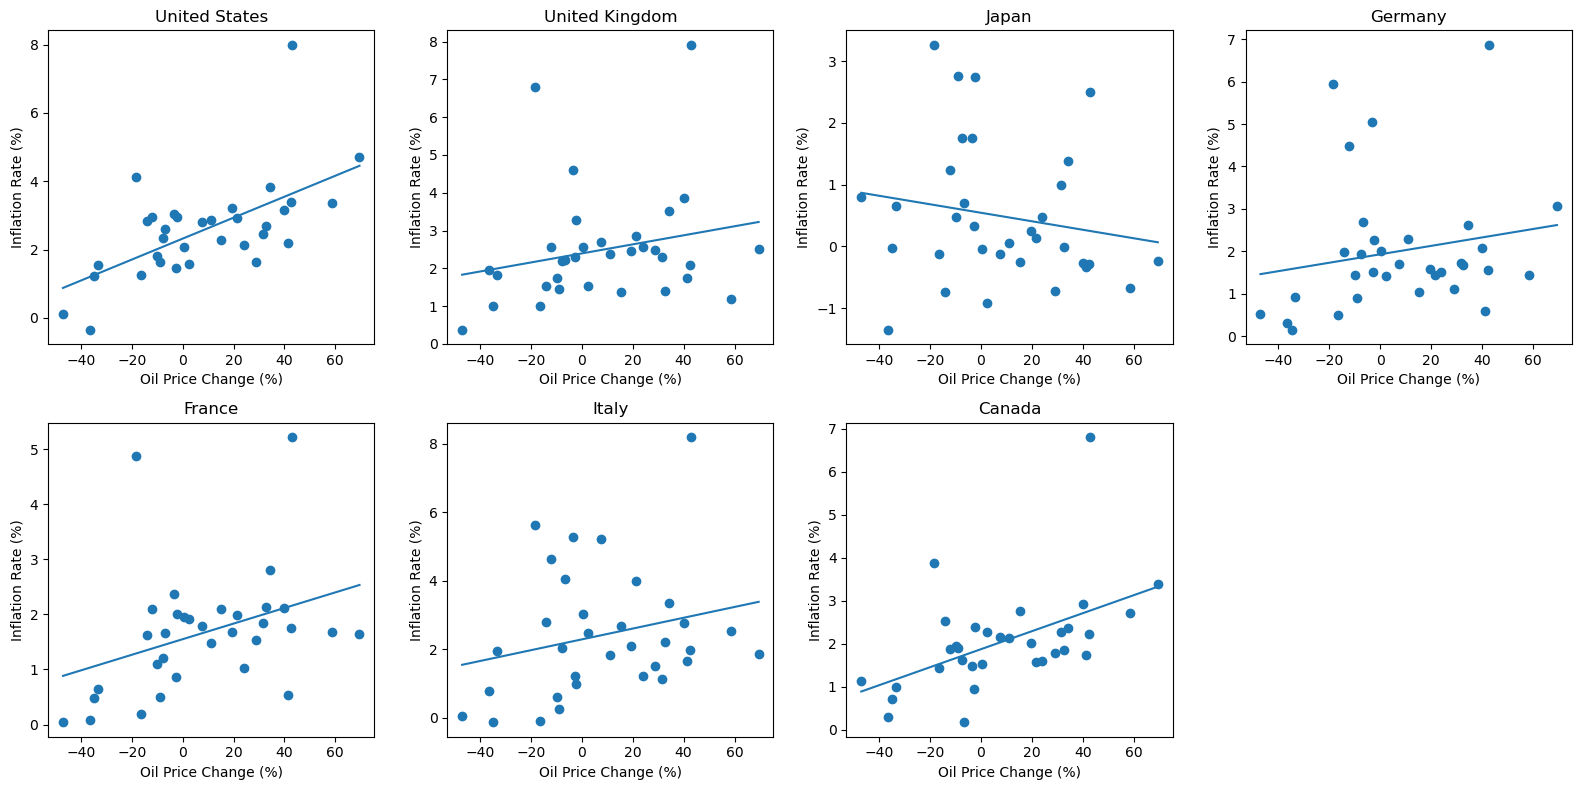

In [92]:
# Figure 1: scatter graph

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(g7_names)):
    country = g7_names[i]
    sub = df[df['Country'] == country]
    m = country_models[country]
    x_line = np.linspace(sub['Oil_Price_Change'].min(), sub['Oil_Price_Change'].max(), 100)

    axes[i].scatter(sub['Oil_Price_Change'], sub['Inflation'])
    axes[i].plot(x_line, m.params['const'] + m.params['Oil_Price_Change'] * x_line)
    axes[i].set_title(country)
    axes[i].set_xlabel('Oil Price Change (%)')
    axes[i].set_ylabel('Inflation Rate (%)')

axes[7].axis('off')
plt.tight_layout()
plt.savefig('fig1_scatter.png')
plt.show()

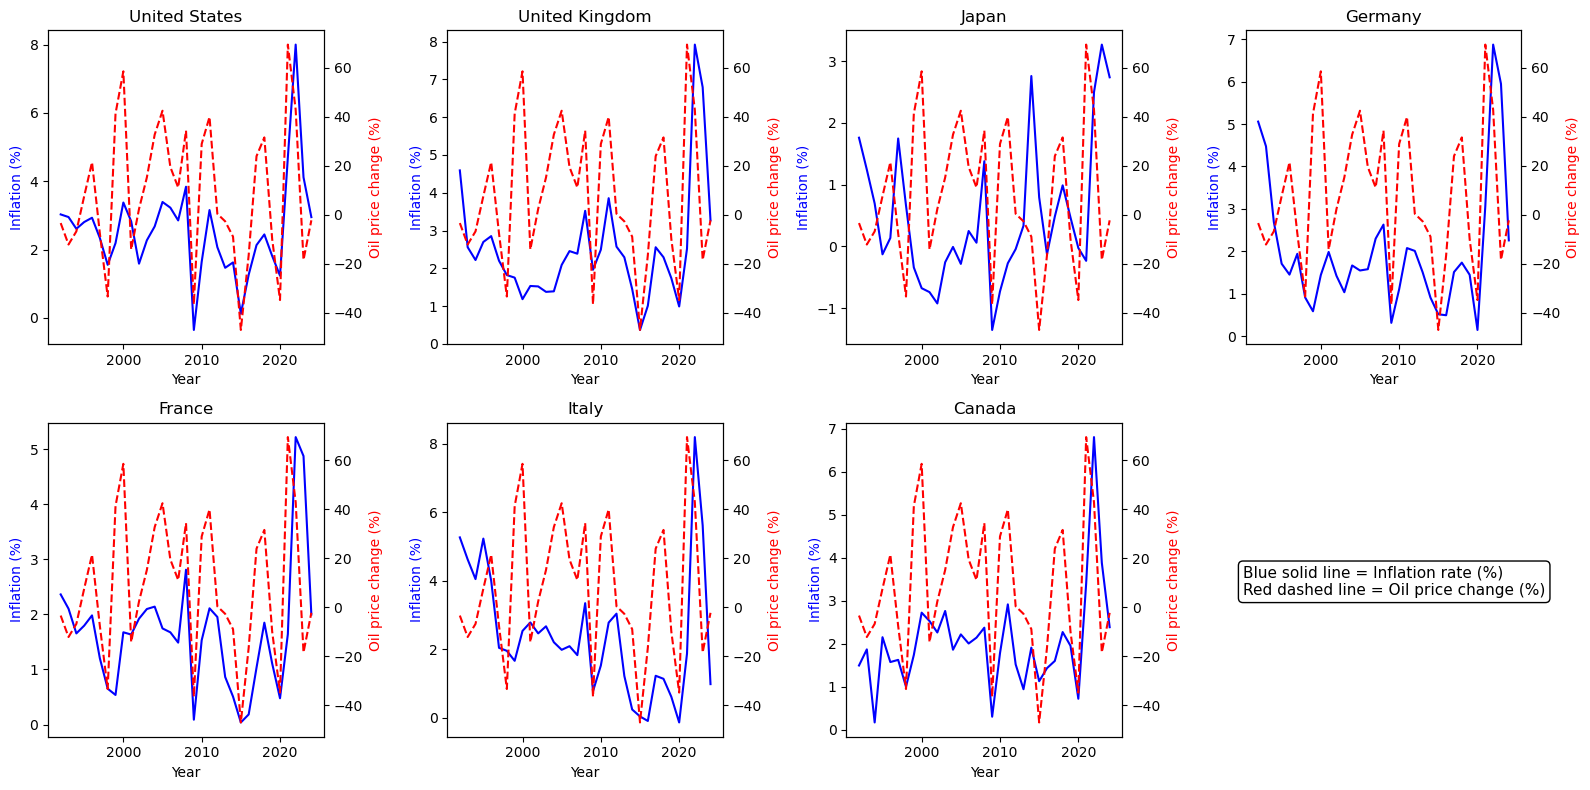

In [93]:
# Figure 2: Time series graph

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(g7_names)):
    country = g7_names[i]
    sub = df[df['Country'] == country]

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(sub['Year'], sub['Inflation'], color='blue')
    ax2.plot(sub['Year'], sub['Oil_Price_Change'], color='red', linestyle='--')

    ax1.set_title(country)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Inflation (%)', color='blue')
    ax2.set_ylabel('Oil price change (%)', color='red')

axes[7].axis('off')
fig.text(0.78, 0.25, 'Blue solid line = Inflation rate (%)\nRed dashed line = Oil price change (%)',
         fontsize=11, bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.savefig('fig2_timeseries.png')
plt.show()

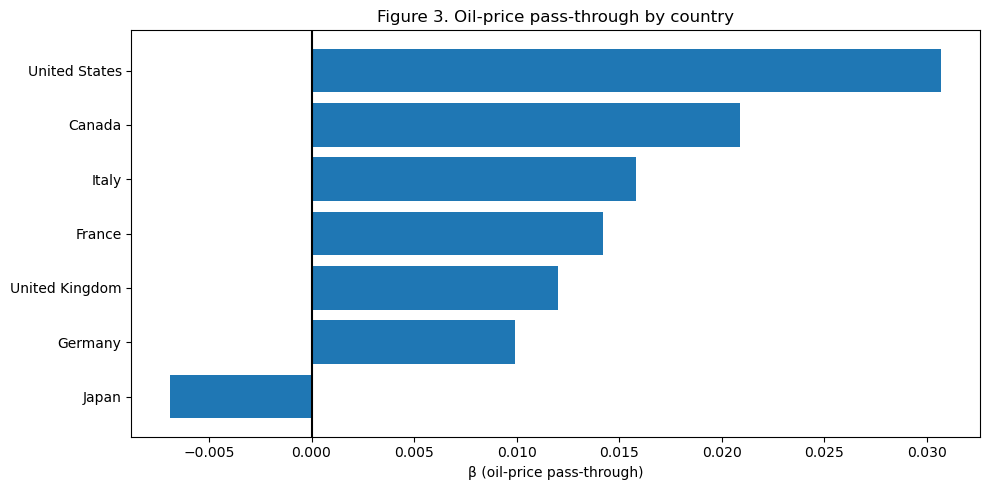

In [94]:
# Figure 3: coefficient bars 

sorted_results = results_df.sort_values('Beta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sorted_results['Country'], sorted_results['Beta'])
ax.axvline(0, color='black')
ax.set_xlabel('β (oil-price pass-through)')
ax.set_title('Figure 3. Oil-price pass-through by country')
plt.tight_layout()
plt.savefig('fig3_beta.png')
plt.show()

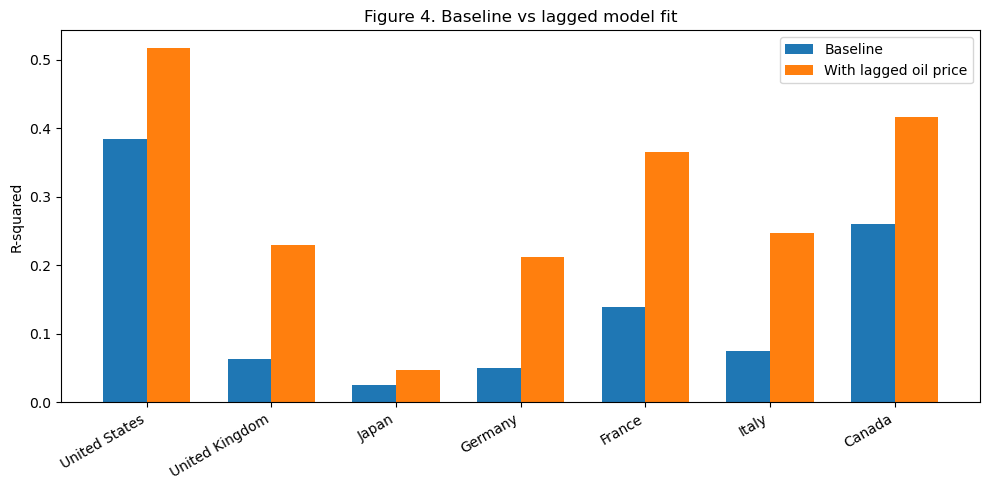

In [95]:
# Figure 4: R² comparison
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison_df['R2_Baseline'], width, label='Baseline')
ax.bar(x + width/2, comparison_df['R2_Lagged'], width, label='With lagged oil price')
ax.set_ylabel('R-squared')
ax.set_title('Figure 4. Baseline vs lagged model fit')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Country'], rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_r2_comparison.png')
plt.show()

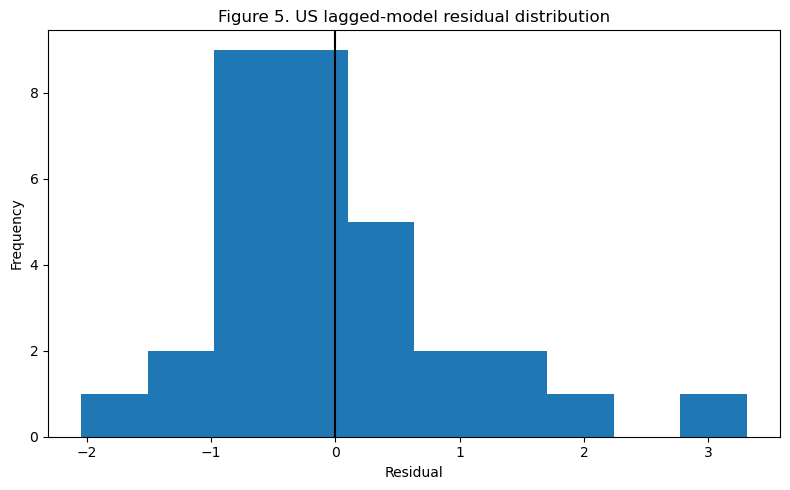

In [96]:
# Figure 5: residuals

resid = lag_models['United States'].resid

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(resid, bins=10)
ax.axvline(0, color='black')
ax.set_title('Figure 5. US lagged-model residual distribution')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('fig5_residuals.png')
plt.show()

In [99]:
# Export 

desc.to_csv('table 1 descriptives.csv')
results_df.to_csv('table 2 country results.csv', index=False)
comparison_df.to_csv('table 3 lag comparison.csv', index=False)
summary_df.to_csv('table 4 summary specifications.csv', index=False)
cumulative_df.to_csv('table 5 cumulative passthrough.csv', index=False)
robustness_df.to_csv('table 6 robustness.csv', index=False)
period_df.to_csv('table subperiod by country.csv', index=False)

print('All tables exported.')
print('Figures saved by Cells 26-30.')

All tables exported.
Figures saved by Cells 26-30.
